In [1]:
import os
import time
import random

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
from tensorflow.keras import models, Sequential, layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import image_dataset_from_directory
import keras_tuner as kt

In [2]:
TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"

# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)

SAVED_MODEL = "cnn_weighted_model.h5"

In [3]:
# Set global random seeds for reproducibility
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [4]:
'''
flow_from_directory is older approach - slower
used image_dataset_from_directory instead for better performance and easier handling of validation split
'''

train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int",
    shuffle=True
)

val_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int",
    subset="validation"
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode = "int"
)

Found 16108 files belonging to 8 classes.
Using 12887 files for training.
Found 16108 files belonging to 8 classes.
Using 3221 files for validation.
Found 14518 files belonging to 8 classes.


In [5]:
train_counts = {}
CLASSES = train_dataset.class_names
num_classes = len(CLASSES)

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)


{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [6]:
'''
Compute class weights from train splitted part only (imbalanced data)
- train_labels is an array of all labels from train dataset.
- concetenate() is used to combine all batches of labels into array
for class weight computation
- y.numpy() is used to convert tensor to numpy array for class weight computation
Class weights змушують loss сильніше штрафувати помилки на rare classes.
'''

train_labels = np.concatenate([y.numpy() for _, y in train_dataset], axis=0)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))

print("Class names:", CLASSES)
print("Class weights:", class_weights)

Class names: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class weights: {0: np.float64(1.3480125523012552), 1: np.float64(1.2887), 2: np.float64(1.6287917087967645), 3: np.float64(1.3525398824517212), 4: np.float64(0.8642033261802575), 5: np.float64(0.7328821656050956), 6: np.float64(0.643063872255489), 7: np.float64(0.9503687315634218)}


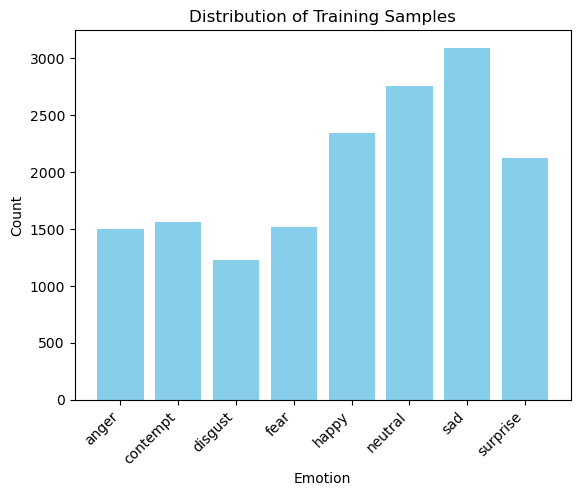

In [7]:
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Training Samples')
plt.show()

In [8]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    layers.RandomRotation(0.05, seed=RANDOM_SEED), # 0.1
    layers.RandomZoom(0.05, seed=RANDOM_SEED),
], name="data_augmentation")

### Keras_tuner: Hyperparameter Tuning

In [ ]:
def build_model(hp):
    base_filters1 = hp.Choice("base_filters1", [32, 48, 64])
    base_filters2 = hp.Choice("base_filters2", [64, 96, 128])
    base_filters3 = hp.Choice("base_filters3", [128, 160, 192])

    dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)

    dense_units = hp.Choice("dense_units", [128, 256, 512])

    l2 = hp.Float("l2", 1e-5, 1e-3, sampling="log")
    lr = hp.Float("lr", 1e-4, 1e-3, sampling="log")

    model = Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(base_filters1, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(base_filters1, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(dropout),

        # Block 2
        layers.Conv2D(base_filters2, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(base_filters2, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(dropout),

        # Block 3
        layers.Conv2D(base_filters3, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(base_filters3, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(dropout),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            dense_units,
            kernel_regularizer=tf.keras.regularizers.l2(l2)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(dropout),

        layers.Dense(8, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=lr,
        weight_decay=l2
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
es = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)
mc = ModelCheckpoint(
    SAVED_MODEL, 
    monitor='val_loss', 
    save_best_only=True
)
csv_logger = CSVLogger("../logs/cnn_training_log.csv")
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [11]:
'''
Initialize a tuner (here, RandomSearch). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
def make_random_search(build_model, project_name, objective, max_trials=20):
    return kt.RandomSearch(
            hypermodel=build_model,
            objective=kt.Objective(objective, direction="min"),
            max_trials=max_trials,
            executions_per_trial=2, # helps to reduce variance by training each model multiple times
            overwrite=True,
            directory='keras_tuner_results',
            project_name=project_name
        )

In [12]:
make_random_search(build_model, "cnn_random", "val_loss", 20).search_space_summary()

Search space summary
Default search space size: 7
base_filters1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 48, 64], 'ordered': True}
base_filters2 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 96, 128], 'ordered': True}
base_filters3 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 160, 192], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
l2 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


In [13]:
tuner = make_random_search(
    build_model,
    project_name="cnn_random",
    objective="val_loss",
    max_trials=5
)

In [14]:
tuner.search(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[rlr, es]
)

Trial 5 Complete [00h 50m 23s]
val_loss: 1.3247827291488647

Best val_loss So Far: 1.3247827291488647
Total elapsed time: 03h 33m 27s


In [15]:
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 372,168 (1.42 MB)

 Trainable params: 370,632 (1.41 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [16]:
best_hp.values

{'base_filters1': 64,
 'base_filters2': 64,
 'base_filters3': 128,
 'dropout': 0.2,
 'dense_units': 256,
 'l2': 1.1248496212634313e-05,
 'lr': 0.0005771238317604307}

In [17]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\cnn_random
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 4 summary
Hyperparameters:
base_filters1: 64
base_filters2: 64
base_filters3: 128
dropout: 0.2
dense_units: 256
l2: 1.1248496212634313e-05
lr: 0.0005771238317604307
Score: 1.3247827291488647

Trial 1 summary
Hyperparameters:
base_filters1: 32
base_filters2: 96
base_filters3: 192
dropout: 0.2
dense_units: 256
l2: 2.4703712312535606e-05
lr: 0.000281116474414401
Score: 1.329977571964264

Trial 3 summary
Hyperparameters:
base_filters1: 32
base_filters2: 64
base_filters3: 128
dropout: 0.30000000000000004
dense_units: 512
l2: 0.0008625204062142954
lr: 0.000716525828993434
Score: 1.384423851966858

Trial 2 summary
Hyperparameters:
base_filters1: 48
base_filters2: 96
base_filters3: 160
dropout: 0.4
dense_units: 512
l2: 1.1607008288598981e-05
lr: 0.00020084655211502806
Score: 1.469927728176117

Trial 0 summary
Hyperparameters:
base_filters1: 32
base_filters2: 128
b

In [18]:
start = time.time()
history = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es, mc, rlr, csv_logger]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.1541 - loss: 2.2106

403/403 ━━━━━━━━━━━━━━━━━━━━ 148s 357ms/step - accuracy: 0.1661 - loss: 2.1622 - val_accuracy: 0.1822 - val_loss: 2.0148 - learning_rate: 5.7712e-04
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.2218 - loss: 1.9640

403/403 ━━━━━━━━━━━━━━━━━━━━ 143s 356ms/step - accuracy: 0.2430 - loss: 1.8794 - val_accuracy: 0.2294 - val_loss: 1.9068 - learning_rate: 5.7712e-04
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.2731 - loss: 1.7007

403/403 ━━━━━━━━━━━━━━━━━━━━ 142s 353ms/step - accuracy: 0.2815 - loss: 1.6881 - val_accuracy: 0.2493 - val_loss: 1.7374 - learning_rate: 5.7712e-04
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.2807 - loss: 1.6344

403/403 ━━━━━━━━━━━━━━━━━━━━ 143s 354ms/step - accuracy: 0.2954 - loss: 1.6258 - val_accuracy: 0.2952 - val_loss: 1.6438 - learning_rate: 5.7712e-04
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 142s 353ms/step - accuracy: 0.3299 - loss: 1.5721 - val_accuracy: 0.2459 - val_loss: 2.5206 - learning_rate: 5.7712e-04
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.3627 - loss: 1.5098

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6552 - loss: 0.9352 - val_accuracy: 0.6172 - val_loss: 0.9997 - learning_rate: 1.4024e-06
Epoch 40/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6538 - loss: 0.9355

403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6611 - loss: 0.9267 - val_accuracy: 0.6175 - val_loss: 0.9997 - learning_rate: 1.4024e-06
Epoch 41/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.6471 - loss: 0.9446

403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6600 - loss: 0.9266 - val_accuracy: 0.6172 - val_loss: 0.9984 - learning_rate: 1.4024e-06
Epoch 42/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 360ms/step - accuracy: 0.6573 - loss: 0.9320 - val_accuracy: 0.6181 - val_loss: 0.9992 - learning_rate: 1.4024e-06
Epoch 43/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 360ms/step - accuracy: 0.6582 - loss: 0.9274 - val_accuracy: 0.6184 - val_loss: 0.9998 - learning_rate: 1.4024e-06
Epoch 44/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 360ms/step - accuracy: 0.6547 - loss: 0.9313 - val_accuracy: 0.6172 - val_loss: 0.9986 - learning_rate: 1.4024e-06
Epoch 45/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6560 - loss: 0.9310 - val_accuracy: 0.6172 - val_loss: 0.9994 - learning_rate: 1.0000e-06
Epoch 46/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 146s 362ms/step - accuracy: 0.6530 - loss: 0.9347 - val_accuracy: 0.6166 - val_loss: 0.9993 - learning_rate: 1.0000e-06
Epoch 47/100
403/403 ━━━━━━━━━━━━━━━━━━━━

403/403 ━━━━━━━━━━━━━━━━━━━━ 146s 362ms/step - accuracy: 0.6531 - loss: 0.9393 - val_accuracy: 0.6178 - val_loss: 0.9976 - learning_rate: 1.0000e-06
Epoch 48/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 146s 361ms/step - accuracy: 0.6590 - loss: 0.9335 - val_accuracy: 0.6181 - val_loss: 0.9984 - learning_rate: 1.0000e-06
Epoch 49/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 360ms/step - accuracy: 0.6551 - loss: 0.9342 - val_accuracy: 0.6191 - val_loss: 0.9988 - learning_rate: 1.0000e-06
Epoch 50/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 147s 365ms/step - accuracy: 0.6510 - loss: 0.9311 - val_accuracy: 0.6181 - val_loss: 0.9985 - learning_rate: 1.0000e-06
Epoch 51/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6447 - loss: 0.9427

403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6573 - loss: 0.9315 - val_accuracy: 0.6181 - val_loss: 0.9973 - learning_rate: 1.0000e-06
Epoch 52/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 360ms/step - accuracy: 0.6574 - loss: 0.9293 - val_accuracy: 0.6184 - val_loss: 0.9979 - learning_rate: 1.0000e-06
Epoch 53/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6551 - loss: 0.9289 - val_accuracy: 0.6194 - val_loss: 0.9983 - learning_rate: 1.0000e-06
Epoch 54/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6577 - loss: 0.9289 - val_accuracy: 0.6194 - val_loss: 0.9987 - learning_rate: 1.0000e-06
Epoch 55/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6568 - loss: 0.9320 - val_accuracy: 0.6188 - val_loss: 0.9981 - learning_rate: 1.0000e-06
Epoch 56/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.6590 - loss: 0.9251 - val_accuracy: 0.6178 - val_loss: 0.9990 - learning_rate: 1.0000e-06
Epoch 57/100
403/403 ━━━━━━━━━━━━━━━━━━━━

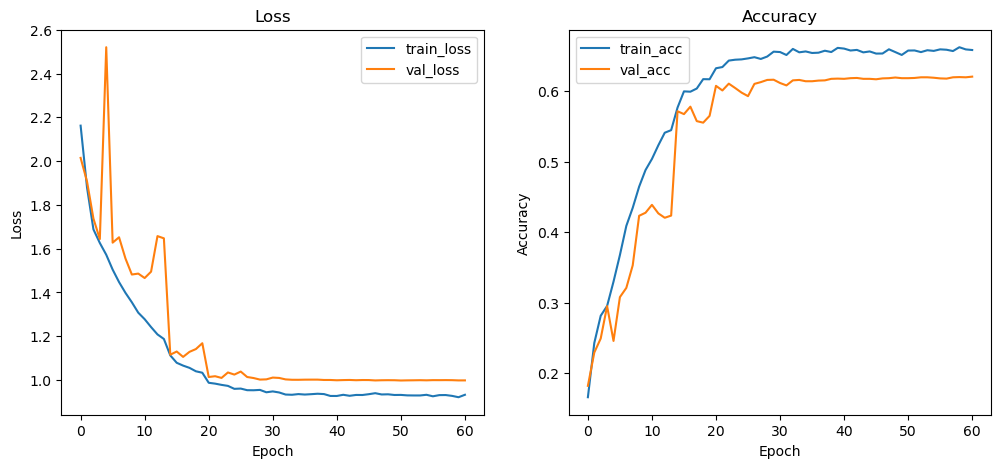

In [19]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [20]:
model = models.load_model(SAVED_MODEL)

In [21]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")

454/454 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - accuracy: 0.6094 - loss: 1.6555
Test Accuracy: 60.94%, Test Loss: 1.6555


454/454 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.6094 - loss: 1.6555
Test Accuracy: 60.94%, Test Loss: 1.6555
454/454 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step
Macro F1: 0.5671
              precision    recall  f1-score   support

       anger       0.49      0.50      0.50      1718
    contempt       0.59      0.60      0.59      1312
     disgust       0.41      0.44      0.42      1248
        fear       0.59      0.38      0.46      1664
       happy       0.89      0.87      0.88      2704
     neutral       0.69      0.92      0.79      2368
         sad       0.48      0.49      0.48      1584
    surprise       0.45      0.38      0.41      1920

    accuracy                           0.61     14518
   macro avg       0.57      0.57      0.57     14518
weighted avg       0.60      0.61      0.60     14518



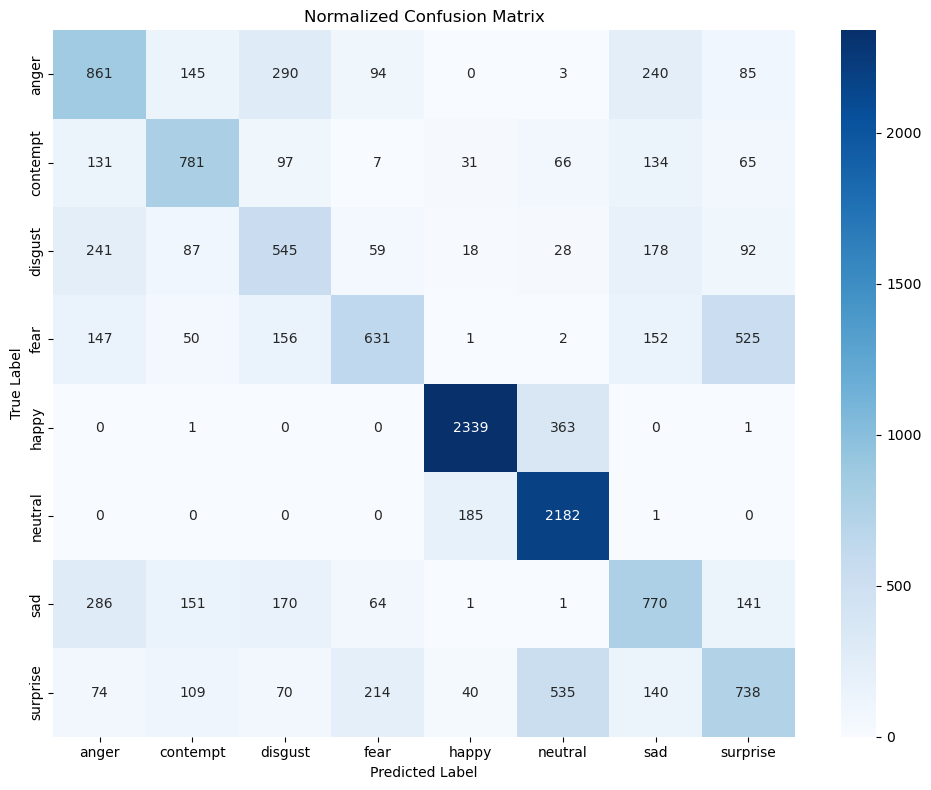

In [22]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")

y_prob = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_dataset], axis=0)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1: {macro_f1:.4f}")

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    zero_division=0
))

cm = confusion_matrix(
    y_true,
    y_pred,
    # labels=np.arange(num_classes),
    # normalize="true"
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

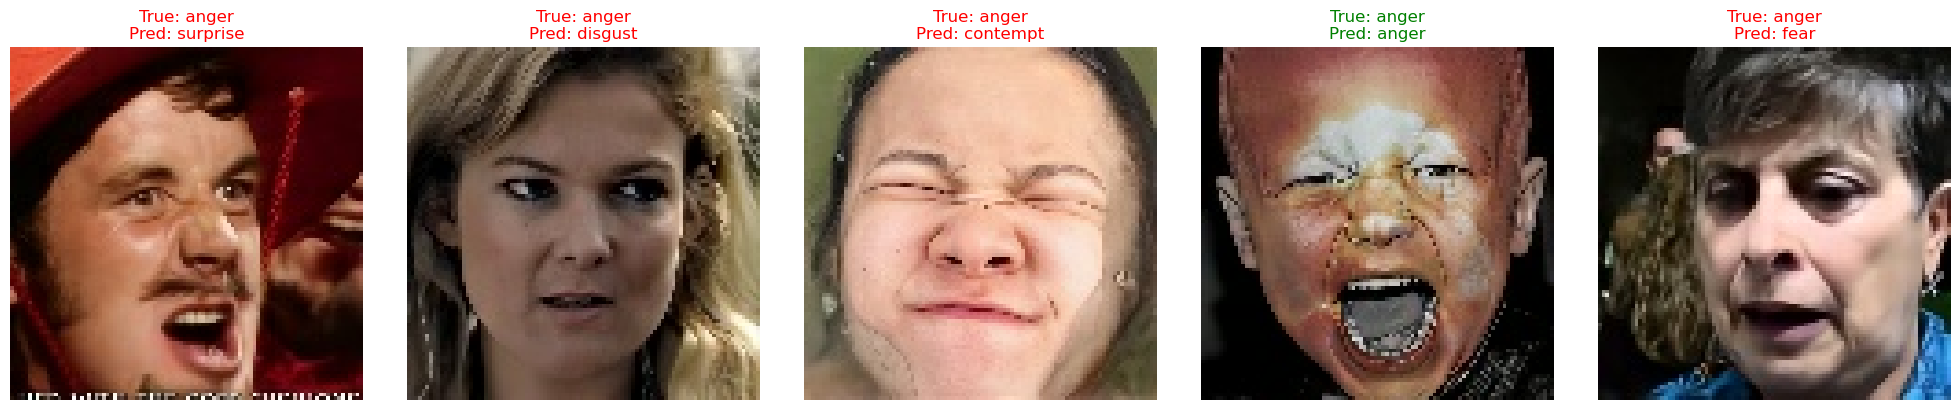

In [23]:
def predict_random_samples():

    # Get one batch
    images, labels = next(iter(test_dataset))

    # Random 5 images
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(len(images), 5, replace=False)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i, idx in enumerate(indices):

        img = images[idx]

        # True label
        true_idx = labels[idx].numpy()
        true_label = CLASSES[true_idx]

        # Prediction
        pred_prob = model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )

        pred_idx = np.argmax(pred_prob)
        pred_label = CLASSES[pred_idx]

        # Plot image
        axes[i].imshow(img.numpy().astype("uint8"))
        axes[i].axis("off")

        # Color
        color = "green" if true_label == pred_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_random_samples()

In [24]:
# Divide by 1024**2 to convert bytes to megabytes
size_mb = os.path.getsize(SAVED_MODEL) / (1024**2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 4.39 MB
